# S1-depeek - Honest de-peeked family-transfer number
**Question.** The famfull headline (MCC 0.37) was best-epoch-ON-TEST (peeking) at max diversity. Under a proper no-test-peek protocol, what is the honest held-out-family number?

*Protocol: 3-way FAMILY split per fold -- TRAIN(286) / EARLY-STOP-VAL(60, family-disjoint) / TEST(60, never used for selection); report TEST at the val-selected epoch. Data: `mmpartnet_out/famfull3_depeek.json`.*

## Definitions / math
- **test@val-epoch (HONEST):** TEST MCC at the epoch maximizing VAL-fold F1 (no test peeking).
- **best-on-test (PEEK):** max TEST MCC over epochs (biased).
- **peeking bias** = best-on-test - test@val-epoch.
- **RNA-only floor** (S3): MCC an RNA-bindability baseline reaches ignoring the protein (= 0.234).
- **protein-family signal** = honest test@val MCC - RNA floor.

In [1]:
import json; from pathlib import Path; from IPython.display import Markdown, display
d = json.loads((Path('..')/'..'/'mmpartnet_out'/'famfull3_depeek.json').read_text())
t = '| fold | best-val epoch | test@val MCC | Acc | last | best-peek |\n|---|---|---|---|---|---|\n'
for f in d['per_fold']:
    t += (f"| {f['fold']} | {f['best_val_epoch']} | {f['test_MCC_at_val']:.3f} | "
          f"{f['test_Acc_at_val']:.3f} | {f['test_MCC_last']:.3f} | {f['test_MCC_bestpeek']:.3f} |\n")
display(Markdown(t)); s = d['summary']
display(Markdown(f"**Honest 5-fold test@val = {s['honest_test_MCC_mean']:.3f} +/- "
  f"{s['honest_test_MCC_std']:.3f}** (Acc {s['honest_test_Acc_mean']:.2f}); best-on-test peek "
  f"{s['bestpeek_MCC_mean']:.3f} (bias {s['peeking_bias']:.3f}); RNA-only floor {s['rna_only_floor']}; "
  f"**protein-family signal above floor {s['protein_signal_above_rna_floor']:.3f} MCC**."))

| fold | best-val epoch | test@val MCC | Acc | last | best-peek |
|---|---|---|---|---|---|
| 0 | 0 | 0.115 | 0.549 | 0.129 | 0.129 |
| 1 | 0 | 0.525 | 0.762 | 0.263 | 0.525 |
| 2 | 0 | 0.387 | 0.690 | 0.472 | 0.485 |
| 3 | 2 | 0.307 | 0.650 | 0.237 | 0.307 |
| 4 | 1 | 0.250 | 0.610 | 0.446 | 0.446 |


**Honest 5-fold test@val = 0.317 +/- 0.137** (Acc 0.65); best-on-test peek 0.378 (bias 0.062); RNA-only floor 0.234; **protein-family signal above floor 0.083 MCC**.

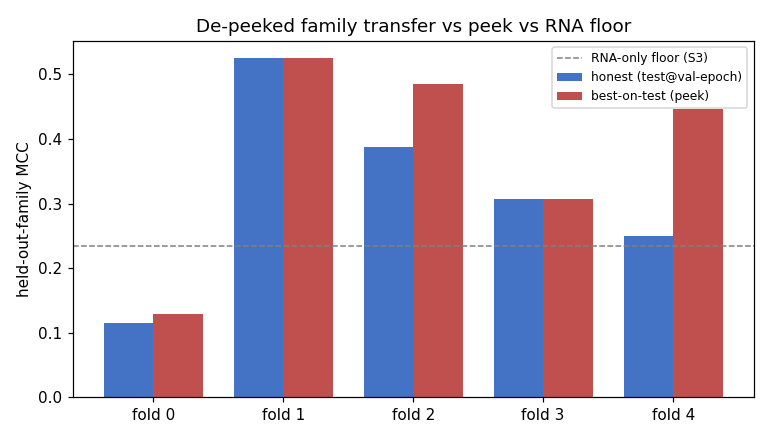

In [2]:
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt, numpy as np
fo=[f['fold'] for f in d['per_fold']]; hv=[f['test_MCC_at_val'] for f in d['per_fold']]; pk=[f['test_MCC_bestpeek'] for f in d['per_fold']]
x=np.arange(len(fo)); w=0.38; fig,ax=plt.subplots(figsize=(7,4))
ax.bar(x-w/2, hv, w, label='honest (test@val-epoch)', color='#4472c4')
ax.bar(x+w/2, pk, w, label='best-on-test (peek)', color='#c0504d')
ax.axhline(0.234, ls='--', c='gray', lw=1, label='RNA-only floor (S3)')
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in fo]); ax.set_ylabel('held-out-family MCC')
ax.set_title('De-peeked family transfer vs peek vs RNA floor'); ax.legend(fontsize=8); fig.tight_layout()
fig.savefig('S1_depeek.png', dpi=110); plt.close(fig)
from IPython.display import Image; display(Image('S1_depeek.png'))

## Conclusion
**Honest de-peeked held-out-family transfer = MCC 0.317 +/- 0.137** (Acc ~0.65). De-peeking does NOT collapse the number (peeking bias only ~0.06; honest 0.317 vs peek 0.378) -- so the famfull signal was not mainly a peeking artifact. BUT the RNA-only baseline already reaches 0.234 (S3), so the **genuine protein-family-transfer signal above the RNA-memorization floor is only ~0.08 MCC**, highly fold-variable (0.12-0.53). The best-val epoch is 0 for 3/5 folds -- training on families barely helps held-family transfer. Net: a real but small protein-family signal on a large RNA-coverage floor; the eye-catching 0.37 was mostly RNA memorization, not clean interpolation. Mechanism follow-up: F1 near-vs-far.

*Provenance: 3-way family split, CORAL model on a CUDA GPU (folds 0,2 salvaged from surviving adapters). `mmpartnet_out/famfull3_depeek.json` + per-fold `famfull3/*/test_metrics.csv`.*